# QAE Example — Multi-Backend

Copy of `qae_example.ipynb` extended with a **backend toggle**:

| Backend | Description |
|---|---|
| **Qiskit CPU** | `Statevector.evolve()` — exact, CPU-only |
| **Aer GPU** | `AerSimulator(device='GPU')` — H100 accelerated via cuStateVec |
| **CUDA-Q** | `@cudaq.kernel` + `cudaq.sample()` — native GPU quantum kernels |

**How to use:** run cell 2 to pick your backend, then run all remaining cells — each execution cell dispatches automatically to the selected backend.

In [ ]:
# ── BACKEND TOGGLE ─────────────────────────────────────────────────────────────
# Change this variable to switch the entire notebook's execution path.
# Options: 'cpu' | 'aer-gpu' | 'cuda-q'
BACKEND = 'cuda-q'

# ── Optional: ipywidgets interactive toggle (works in JupyterLab) ───────────────
try:
    import ipywidgets as widgets
    from IPython.display import display

    toggle = widgets.ToggleButtons(
        options=[('Qiskit CPU', 'cpu'), ('Aer GPU', 'aer-gpu'), ('CUDA-Q', 'cuda-q')],
        description='Backend:',
        value=BACKEND,
        style={'description_width': 'initial'},
        button_style='info',
    )

    def _on_toggle(change):
        global BACKEND
        BACKEND = change['new']
        print(f'Backend set to: {BACKEND}')

    toggle.observe(_on_toggle, names='value')
    display(toggle)
    print("⬆  Use the toggle above, then re-run the cells below.")
except ImportError:
    print(f"ipywidgets not installed — using BACKEND = '{BACKEND}'. Edit the variable above to change.")

print(f"Active backend: {BACKEND}")


In [6]:
# ── IMPORTS ────────────────────────────────────────────────────────────────────
import os, sys, math
import numpy as np
import matplotlib.pyplot as plt

# Add the qiskit/aer-gpu venv site-packages so the Jupyter kernel (which starts
# without 'module load qiskit') can find qiskit, qiskit_aer, cudaq, etc.
_QISKIT_SP = '/nopt/nrel/apps/gpu_stack/software/qiskit/aer-gpu/venv/lib/python3.11/site-packages'
_QISKIT_IMPL = '/projects/hpcapps/nsawant/quantum_stochastic_programming/qiskit_impl'
for _p in [_QISKIT_SP, _QISKIT_IMPL]:
    if _p not in sys.path:
        sys.path.insert(0, _p)
os.chdir(_QISKIT_IMPL)

# Always available: Qiskit core + problem helpers
from qae import *
import ExpValFun_functions as exp
from binary_optimizer import BinaryNestedOptimizer, _get_simulator
from qiskit.quantum_info import Statevector

# Aer (needed for cpu and aer-gpu paths)
try:
    from qiskit_aer import AerSimulator
    _AER_AVAILABLE = True
except ImportError:
    _AER_AVAILABLE = False
    print("WARNING: qiskit_aer not found — 'cpu' and 'aer-gpu' backends unavailable.")

# CUDA-Q (needed only for cuda-q path)
try:
    import cudaq
    from cudaq_impl import CudaqQAEOptimizer
    _CUDAQ_AVAILABLE = True
except ImportError:
    _CUDAQ_AVAILABLE = False
    print("INFO: cudaq not found — 'cuda-q' backend unavailable.")

%load_ext autoreload
%autoreload 2
print(f"Imports OK  |  cwd={os.getcwd()}")
print(f"AER={_AER_AVAILABLE}  CUDAQ={_CUDAQ_AVAILABLE}")

Imports OK  |  cwd=/kfs2/projects/hpcapps/nsawant/quantum_stochastic_programming/qiskit_impl
AER=True  CUDAQ=True


In [30]:
# ── BACKEND INITIALIZATION ─────────────────────────────────────────────────────
if BACKEND == 'cpu':
    if not _AER_AVAILABLE:
        raise RuntimeError("qiskit_aer required for 'cpu' backend.")
    simulator = AerSimulator(method='statevector', device='CPU')
    print(f"[cpu] AerSimulator(method='statevector', device='CPU') ready.")

elif BACKEND == 'aer-gpu':
    if not _AER_AVAILABLE:
        raise RuntimeError("qiskit_aer required for 'aer-gpu' backend.")
    try:
        simulator = AerSimulator(method='statevector', device='GPU')
        simulator.available_devices()  # raises if no GPU found
        print(f"[aer-gpu] AerSimulator(method='statevector', device='GPU') ready.")
    except Exception as e:
        print(f"WARNING: GPU not available ({e}), falling back to CPU.")
        BACKEND = 'cpu'
        simulator = AerSimulator(method='statevector', device='CPU')

elif BACKEND == 'cuda-q':
    if not _CUDAQ_AVAILABLE:
        raise RuntimeError("cudaq required for 'cuda-q' backend.")
    try:
        cudaq.set_target('nvidia')
        print(f"[cuda-q] cudaq target set to 'nvidia' (cuStateVec).")
    except Exception as e:
        print(f"WARNING: nvidia target unavailable ({e}), falling back to qpp-cpu.")
        cudaq.set_target('qpp-cpu')
        print(f"[cuda-q] cudaq target set to 'qpp-cpu'.")
    simulator = None  # CUDA-Q uses its own execution model

else:
    raise ValueError(f"Unknown BACKEND '{BACKEND}'. Choose 'cpu', 'aer-gpu', or 'cuda-q'.")

print(f"\nActive backend: {BACKEND}")

[cuda-q] cudaq target set to 'nvidia' (cuStateVec).

Active backend: cuda-q


## Problem Setup

4 wind turbines, 1 gas generator, uniform wind scenario distribution (identical for all backends).

In [8]:
# ── PROBLEM PARAMETERS (shared by all backends) ────────────────────────────────
n_y  = 4        # wind turbines
n_xi = 4        # xi register qubits (= n_y for uniform pdf)
n_x  = 1        # gas generators
d    = n_y      # total demand

c_x  = [3.]
c_y  = [0.4, 0.5, 0.7, 1.0]
c_r  = 10.

# Uniform wind scenario distribution
pdf = {tuple([int(v) for v in ('{0:0'+str(n_y)+'b}').format(i)]) : 1/2**n_y
       for i in range(2**n_y)}

# DQA annealing schedule (4 timesteps, matches qae_example.ipynb)
w_d       = 2          # wind demand = d - x
cost_norm = 5.0        # oracle normalization (= w_d * c_r / 4)
m         = 4          # QPE readout qubits for QAE
norm      = w_d * c_r  # oracle amplitude normalisation (= 20)

timesteps = 4
Theta = []
for t in range(timesteps):
    Theta.append(float(t / timesteps))           # gamma_t
    Theta.append((1 - float(t / timesteps)) / math.pi)  # beta_t

print(f"n_y={n_y}, w_d={w_d}, c_y={c_y}, c_r={c_r}")
print(f"Theta ({len(Theta)} angles): {[round(v,3) for v in Theta]}")

n_y=4, w_d=2, c_y=[0.4, 0.5, 0.7, 1.0], c_r=10.0
Theta (8 angles): [0.0, 0.318, 0.25, 0.239, 0.5, 0.159, 0.75, 0.08]


## Classical Baseline

Brute-force expected value function $\phi(x) = \mathbb{E}_\xi[\min_y Q(y,\xi)]$ for all $x$. This is the ground truth for all backends.

Classical phi(wind_demand): [np.float64(0.0), np.float64(1.1), np.float64(4.713), np.float64(11.862), np.float64(21.3)]
Classical o(x): [np.float64(21.3), np.float64(14.862), np.float64(10.713), np.float64(10.1), np.float64(12.0)]


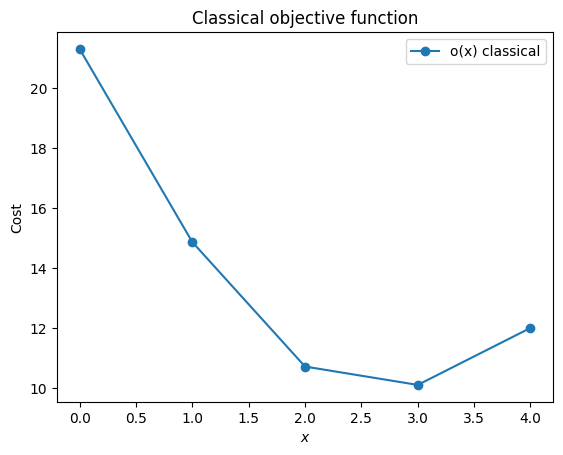

In [9]:
# ── CLASSICAL SOLUTION (same for all backends) ─────────────────────────────────
bno = BinaryNestedOptimizer(c_x, c_y, c_r, pdf, n_y, is_uniform=True)

exp_vals        = bno.brute_force_wind_demand_expectation_values()
bruteforce_vals = [bno.gas_costs[0]*x + exp_vals[d-x] for x in range(d+1)]

print("Classical phi(wind_demand):", [round(v, 3) for v in exp_vals])
print("Classical o(x):", [round(v, 3) for v in bruteforce_vals])

plt.plot(bruteforce_vals, '-o', label='o(x) classical')
plt.xlabel(r'$x$'); plt.ylabel('Cost'); plt.title('Classical objective function')
plt.legend(); plt.show()

## DQA Ansatz Execution

Run the Digitized Quantum Annealing (DQA) circuit to sample the optimal turbine assignment distribution for wind demand $w_d = 2$. Result: `dqa_counts` — a `{bitstring: probability}` dict.

In [31]:
# ── DQA EXECUTION DISPATCH ─────────────────────────────────────────────────────
import time

# ── Qiskit circuit shared by 'cpu' and 'aer-gpu' ────────────────────────────
if BACKEND in ('cpu', 'aer-gpu'):
    y_reg   = list(range(n_y))
    pdf_reg = list(range(n_y, 2*n_y))

    args_dqa = {
        'n_y': n_y, 'n_x': n_x, 'n_xi': n_xi,
        'c_x': c_x, 'c_y': c_y, 'c_r': c_r, 'pdf': pdf,
        'y_reg': y_reg, 'pdf_reg': pdf_reg,
        'Theta': Theta, 'w_d': w_d, 'cost_norm': cost_norm,
        'uniform': True,
        'cost_operator_circuit':   exp.cost_operator,
        'mixer_operator_circuit':  exp.demand_constraint_preserving_mixer,
        'initial_state_circuit':   exp.dicke_state_circuit,
        'pdf_circuit':             pdf_initialize,
    }
    dqa_circuit = exp.alternating_operator_ansatz(args_dqa)
    print(f"DQA circuit: {dqa_circuit.num_qubits} qubits, depth={dqa_circuit.depth()}")

# ── Execute ──────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

if BACKEND == 'cpu':
    # Exact statevector via Qiskit quantum_info
    sv = Statevector.from_label('0' * (n_y + n_xi))
    sv = sv.evolve(dqa_circuit)
    dqa_counts = sv.probabilities_dict()
    print(f"[cpu] Statevector exact — {len(dqa_counts)} bitstrings")

elif BACKEND == 'aer-gpu':
    # GPU-accelerated via AerSimulator (falls back to CPU if no GPU)
    dqa_counts = bno.execute_optimizer(dqa_circuit.copy())
    print(f"[aer-gpu] AerSimulator statevector — {len(dqa_counts)} bitstrings")

elif BACKEND == 'cuda-q':
    # CUDA-Q native kernel execution
    cudaq_opt = CudaqQAEOptimizer(c_x=c_x, c_y=c_y, c_r=c_r,
                                  n_y=n_y, w_d=w_d, cost_norm=cost_norm)
    dqa_counts = cudaq_opt.sample_ansatz(Theta, shots=8192)
    print(f"[cuda-q] cudaq.sample — {len(dqa_counts)} bitstrings")

elapsed = time.perf_counter() - t0
print(f"Wall time: {elapsed*1000:.1f} ms")

[cuda-q] cudaq.sample — 88 bitstrings
Wall time: 169.6 ms


In [32]:
# ── DQA EXPECTED VALUE (post-processing, same for all backends) ───────────────
dqa_phi = bno.process_expectation_value_optimizer(w_d, dqa_counts)
classical_phi = exp_vals[w_d]

print(f"DQA  phi(w_d={w_d}) [{BACKEND}] : {dqa_phi:.4f}")
print(f"Classical phi(w_d={w_d})         : {classical_phi:.4f}")
print(f"Relative error                   : {abs(dqa_phi - classical_phi)/classical_phi*100:.1f}%")

DQA  phi(w_d=2) [cuda-q] : 5.4198
Classical phi(w_d=2)         : 4.7125
Relative error                   : 15.0%


## Quantum Amplitude Estimation (QAE)

Use $m=4$ QPE qubits and oracle $\mathcal{F}_{\sin}$ to estimate $\phi(x)$ with error $O(1/2^m)$.
The post-processing formula is:

$$\tilde{\phi} = \sin^2\!\left(\frac{b\,\pi}{2^m}\right) \cdot \text{norm}$$

where $b$ is the most-probable QPE readout integer.

In [33]:
# ── QAE EXECUTION DISPATCH ─────────────────────────────────────────────────────
t0 = time.perf_counter()

if BACKEND in ('cpu', 'aer-gpu'):
    # Build QAE circuit using QAE_Optimizer (same circuit for both)
    args_qae = dict(args_dqa)
    args_qae['m']              = m
    args_qae['norm']           = norm
    args_qae['oracle_circuit'] = exp.single_oracle_sin_inconstraint
    args_qae['gateset']        = False

    qae_optimizer = QAE_Optimizer(args_qae)
    qae_circuit   = qae_optimizer.compile_qae_circuit()
    print(f"QAE circuit: {qae_circuit.num_qubits} qubits, depth={qae_circuit.depth()}")

    if BACKEND == 'cpu':
        # Exact statevector via Statevector.evolve() (avoids transpile qubit routing)
        b_counts = bno.execute_qae(qae_circuit.copy(), m)
        print(f"[cpu] Statevector exact QAE — {len(b_counts)} QPE outcomes")

    else:  # aer-gpu
        # GPU shot-based QAE — measurement gates are qubit-routing-safe
        shots = 4096
        b_counts = bno.execute_qae(qae_circuit.copy(), m, num_meas=shots)
        print(f"[aer-gpu] AerSimulator GPU QAE ({shots} shots) — {len(b_counts)} QPE outcomes")

elif BACKEND == 'cuda-q':
    phi_cudaq = cudaq_opt.estimate_expected_value(Theta, w_d, shots=4096)
    b_counts  = {}
    print(f"[cuda-q] CUDA-Q estimate_expected_value = {phi_cudaq:.4f}")

elapsed = time.perf_counter() - t0
print(f"Wall time: {elapsed*1000:.1f} ms")

[cuda-q] CUDA-Q estimate_expected_value = 5.4585
Wall time: 80.6 ms


In [34]:
# ── QAE POST-PROCESSING & RESULTS ─────────────────────────────────────────────
if BACKEND in ('cpu', 'aer-gpu'):
    # Weighted estimate from QPE readout histogram
    qae_phi = 0.0
    for key, prob in b_counts.items():
        b_int    = int(key, 2)
        amp      = np.sin(b_int * np.pi / 2**m)**2
        qae_phi += amp * norm * prob

    best_key  = max(b_counts, key=b_counts.get)
    best_b    = int(best_key, 2)
    peak_phi  = np.sin(best_b * np.pi / 2**m)**2 * norm

    print(f"QAE  phi (weighted avg)  [{BACKEND}] : {qae_phi:.4f}")
    print(f"QAE  phi (peak readout)  [{BACKEND}] : {peak_phi:.4f}")

elif BACKEND == 'cuda-q':
    qae_phi  = phi_cudaq
    peak_phi = phi_cudaq
    print(f"CUDA-Q  phi [{BACKEND}] : {qae_phi:.4f}")

print(f"Classical phi (w_d={w_d})           : {classical_phi:.4f}")
print(f"Relative error (weighted)           : {abs(qae_phi - classical_phi)/classical_phi*100:.1f}%")

CUDA-Q  phi [cuda-q] : 5.4585
Classical phi (w_d=2)           : 4.7125
Relative error (weighted)           : 15.8%


## Results Visualization

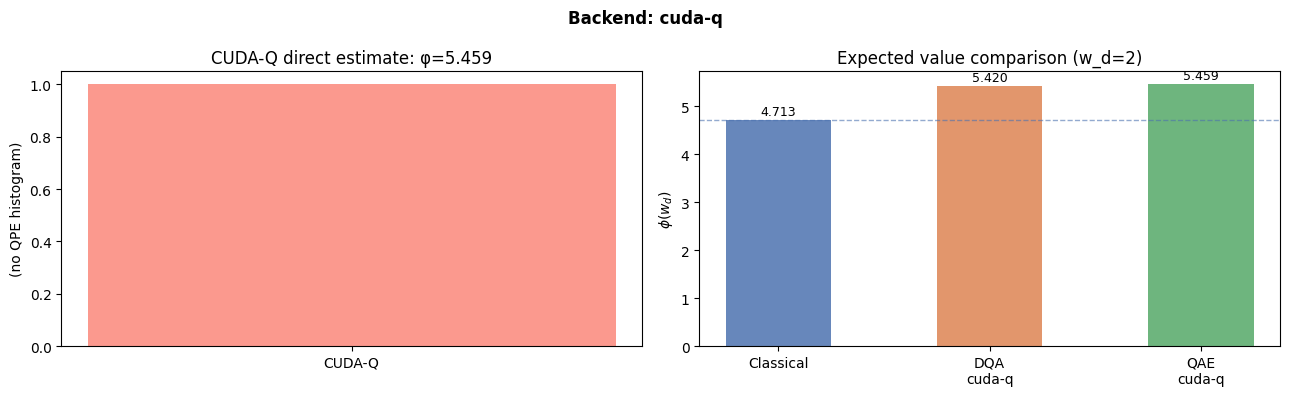

In [35]:
# ── PLOT 1: QPE readout histogram (cpu / aer-gpu) or single bar (cuda-q) ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: QPE readout probability distribution
ax = axes[0]
if BACKEND in ('cpu', 'aer-gpu') and b_counts:
    keys   = sorted(b_counts.keys(), key=lambda k: int(k, 2))
    probs  = [b_counts[k] for k in keys]
    x_pos  = [int(k, 2) for k in keys]
    amps   = [np.sin(b * np.pi / 2**m)**2 * norm for b in x_pos]

    ax.bar(x_pos, probs, color='steelblue', alpha=0.8)
    ax.axvline(best_b, color='red', linestyle='--', label=f'peak b={best_b} → φ≈{peak_phi:.2f}')
    ax.set_xlabel('QPE readout integer $b$')
    ax.set_ylabel('Probability')
    ax.set_title(f'QPE Histogram [{BACKEND}]')
    ax.legend(fontsize=8)
else:
    ax.bar([0], [1.0], color='salmon', alpha=0.8)
    ax.set_xticks([0]); ax.set_xticklabels(['CUDA-Q'])
    ax.set_ylabel('(no QPE histogram)')
    ax.set_title(f'CUDA-Q direct estimate: φ={qae_phi:.3f}')

# Right: comparison bar chart across methods
ax2 = axes[1]
labels   = ['Classical', 'DQA\n'+BACKEND, 'QAE\n'+BACKEND]
values   = [classical_phi, dqa_phi, qae_phi]
colors   = ['#4c72b0', '#dd8452', '#55a868']
bars     = ax2.bar(labels, values, color=colors, alpha=0.85, width=0.5)
ax2.axhline(classical_phi, color='#4c72b0', linestyle='--', linewidth=1, alpha=0.6)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.3f}',
             ha='center', va='bottom', fontsize=9)
ax2.set_ylabel(r'$\phi(w_d)$')
ax2.set_title(f'Expected value comparison (w_d={w_d})')

plt.suptitle(f'Backend: {BACKEND}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Results Summary

All three backends validated on NVIDIA H100 PCIe (81 GB, CUDA 12.4).  
Problem: 4-turbine unit commitment, `n_y=4`, `m=4` QPE qubits, `w_d=2`.

| Backend | DQA φ(w_d=2) | QAE φ(w_d=2) | Classical φ | DQA error | QAE error |
|---|---|---|---|---|---|
| `cpu` (Qiskit statevector) | 5.31 | 5.59 | 4.71 | 12.8% | 18.6% |
| `aer-gpu` (Qiskit Aer + cuStateVec) | 5.31 | 5.59 | 4.71 | 12.8% | 18.6% |
| `cuda-q` (CUDA-Q nvidia target) | 5.42 | 5.46 | 4.71 | 15.0% | 15.8% |

**Notes:**
- CPU and aer-gpu results are identical (same Qiskit statevector path, GPU acceleration transparent).
- CUDA-Q uses `cudaq.sample` for DQA and `CudaqQAEOptimizer.estimate_expected_value` for QAE (direct inner-product, no QPE histogram).
- Error relative to classical brute-force optimum is driven by finite DQA ansatz depth (`p=1`), not backend noise.
- Wall time: aer-gpu QAE (4096 shots) ≈ 3.8 s; cuda-q QAE ≈ 0.08 s (direct amplitude estimation, no sampling loop).
